In [1]:
# LIBRARIES
# Numerical and Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# File Operations
import os

# Statistical Analysis
from scipy.stats import linregress

# Machine Learning Models
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Data Splitting
from sklearn.model_selection import train_test_split

# Evaluation Metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

# Explainable AI
import shap

In [2]:
# Read the data
data = pd.read_excel(r"C:\Users\verma\Downloads\updated data.xlsx")
data.shape

(669, 5)

In [3]:
# 1. Inspect the dataset
print(data.head())
print(data.info())
print(data.describe())

         Ca          Re        We        Bo       Ꟙ/r
0  0.000765   90.841520  0.069463  0.231109  0.012720
1  0.001369  162.635625  0.222648  0.231109  0.017471
2  0.002479  294.502348  0.730071  0.231109  0.026360
3  0.003293  391.204611  1.288237  0.231109  0.027433
4  0.004366  518.675777  2.264538  0.231109  0.041992
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ca      669 non-null    float64
 1   Re      669 non-null    float64
 2   We      669 non-null    float64
 3   Bo      669 non-null    float64
 4   Ꟙ/r     669 non-null    float64
dtypes: float64(5)
memory usage: 26.3 KB
None
               Ca           Re           We          Bo         Ꟙ/r
count  669.000000   669.000000   669.000000  669.000000  669.000000
mean     0.059959   750.620089    60.637075    0.427499    0.124901
std      0.079517   879.122244   137.158703    0.618347    0.06

In [4]:
# 2. Check for missing values
# -----------------------------
print("\nMissing Values:")
print(data.isnull().sum())
# Remove rows with missing values
data = data.dropna()
data.shape


Missing Values:
Ca     0
Re     0
We     0
Bo     0
Ꟙ/r    0
dtype: int64


(669, 5)

In [5]:
# 3. Check for duplicate records

print("\nDuplicate Rows:", data.duplicated().sum())
# Remove duplicates
data = data.drop_duplicates()
data.shape


Duplicate Rows: 0


(669, 5)

In [6]:
# 4. Descriptive statistics
stats_table = data.describe().T

# Add variance and coefficient of variation (optional)
stats_table["Variance"] = data.var()
stats_table["CV (%)"] = (data.std() / data.mean()) * 100

# Round values
stats_table = stats_table.round(2)

print(stats_table)

     count    mean     std   min     25%     50%      75%      max   Variance  \
Ca   669.0    0.06    0.08  0.00    0.01    0.03     0.08     0.94       0.01   
Re   669.0  750.62  879.12  0.01  104.43  376.95  1142.03  4719.45  772855.92   
We   669.0   60.64  137.16  0.00    1.59   14.62    59.72  1821.89   18812.51   
Bo   669.0    0.43    0.62  0.01    0.09    0.28     0.57     5.21       0.38   
Ꟙ/r  669.0    0.12    0.06  0.01    0.07    0.12     0.17     0.32       0.00   

     CV (%)  
Ca   132.62  
Re   117.12  
We   226.20  
Bo   144.64  
Ꟙ/r   51.27  


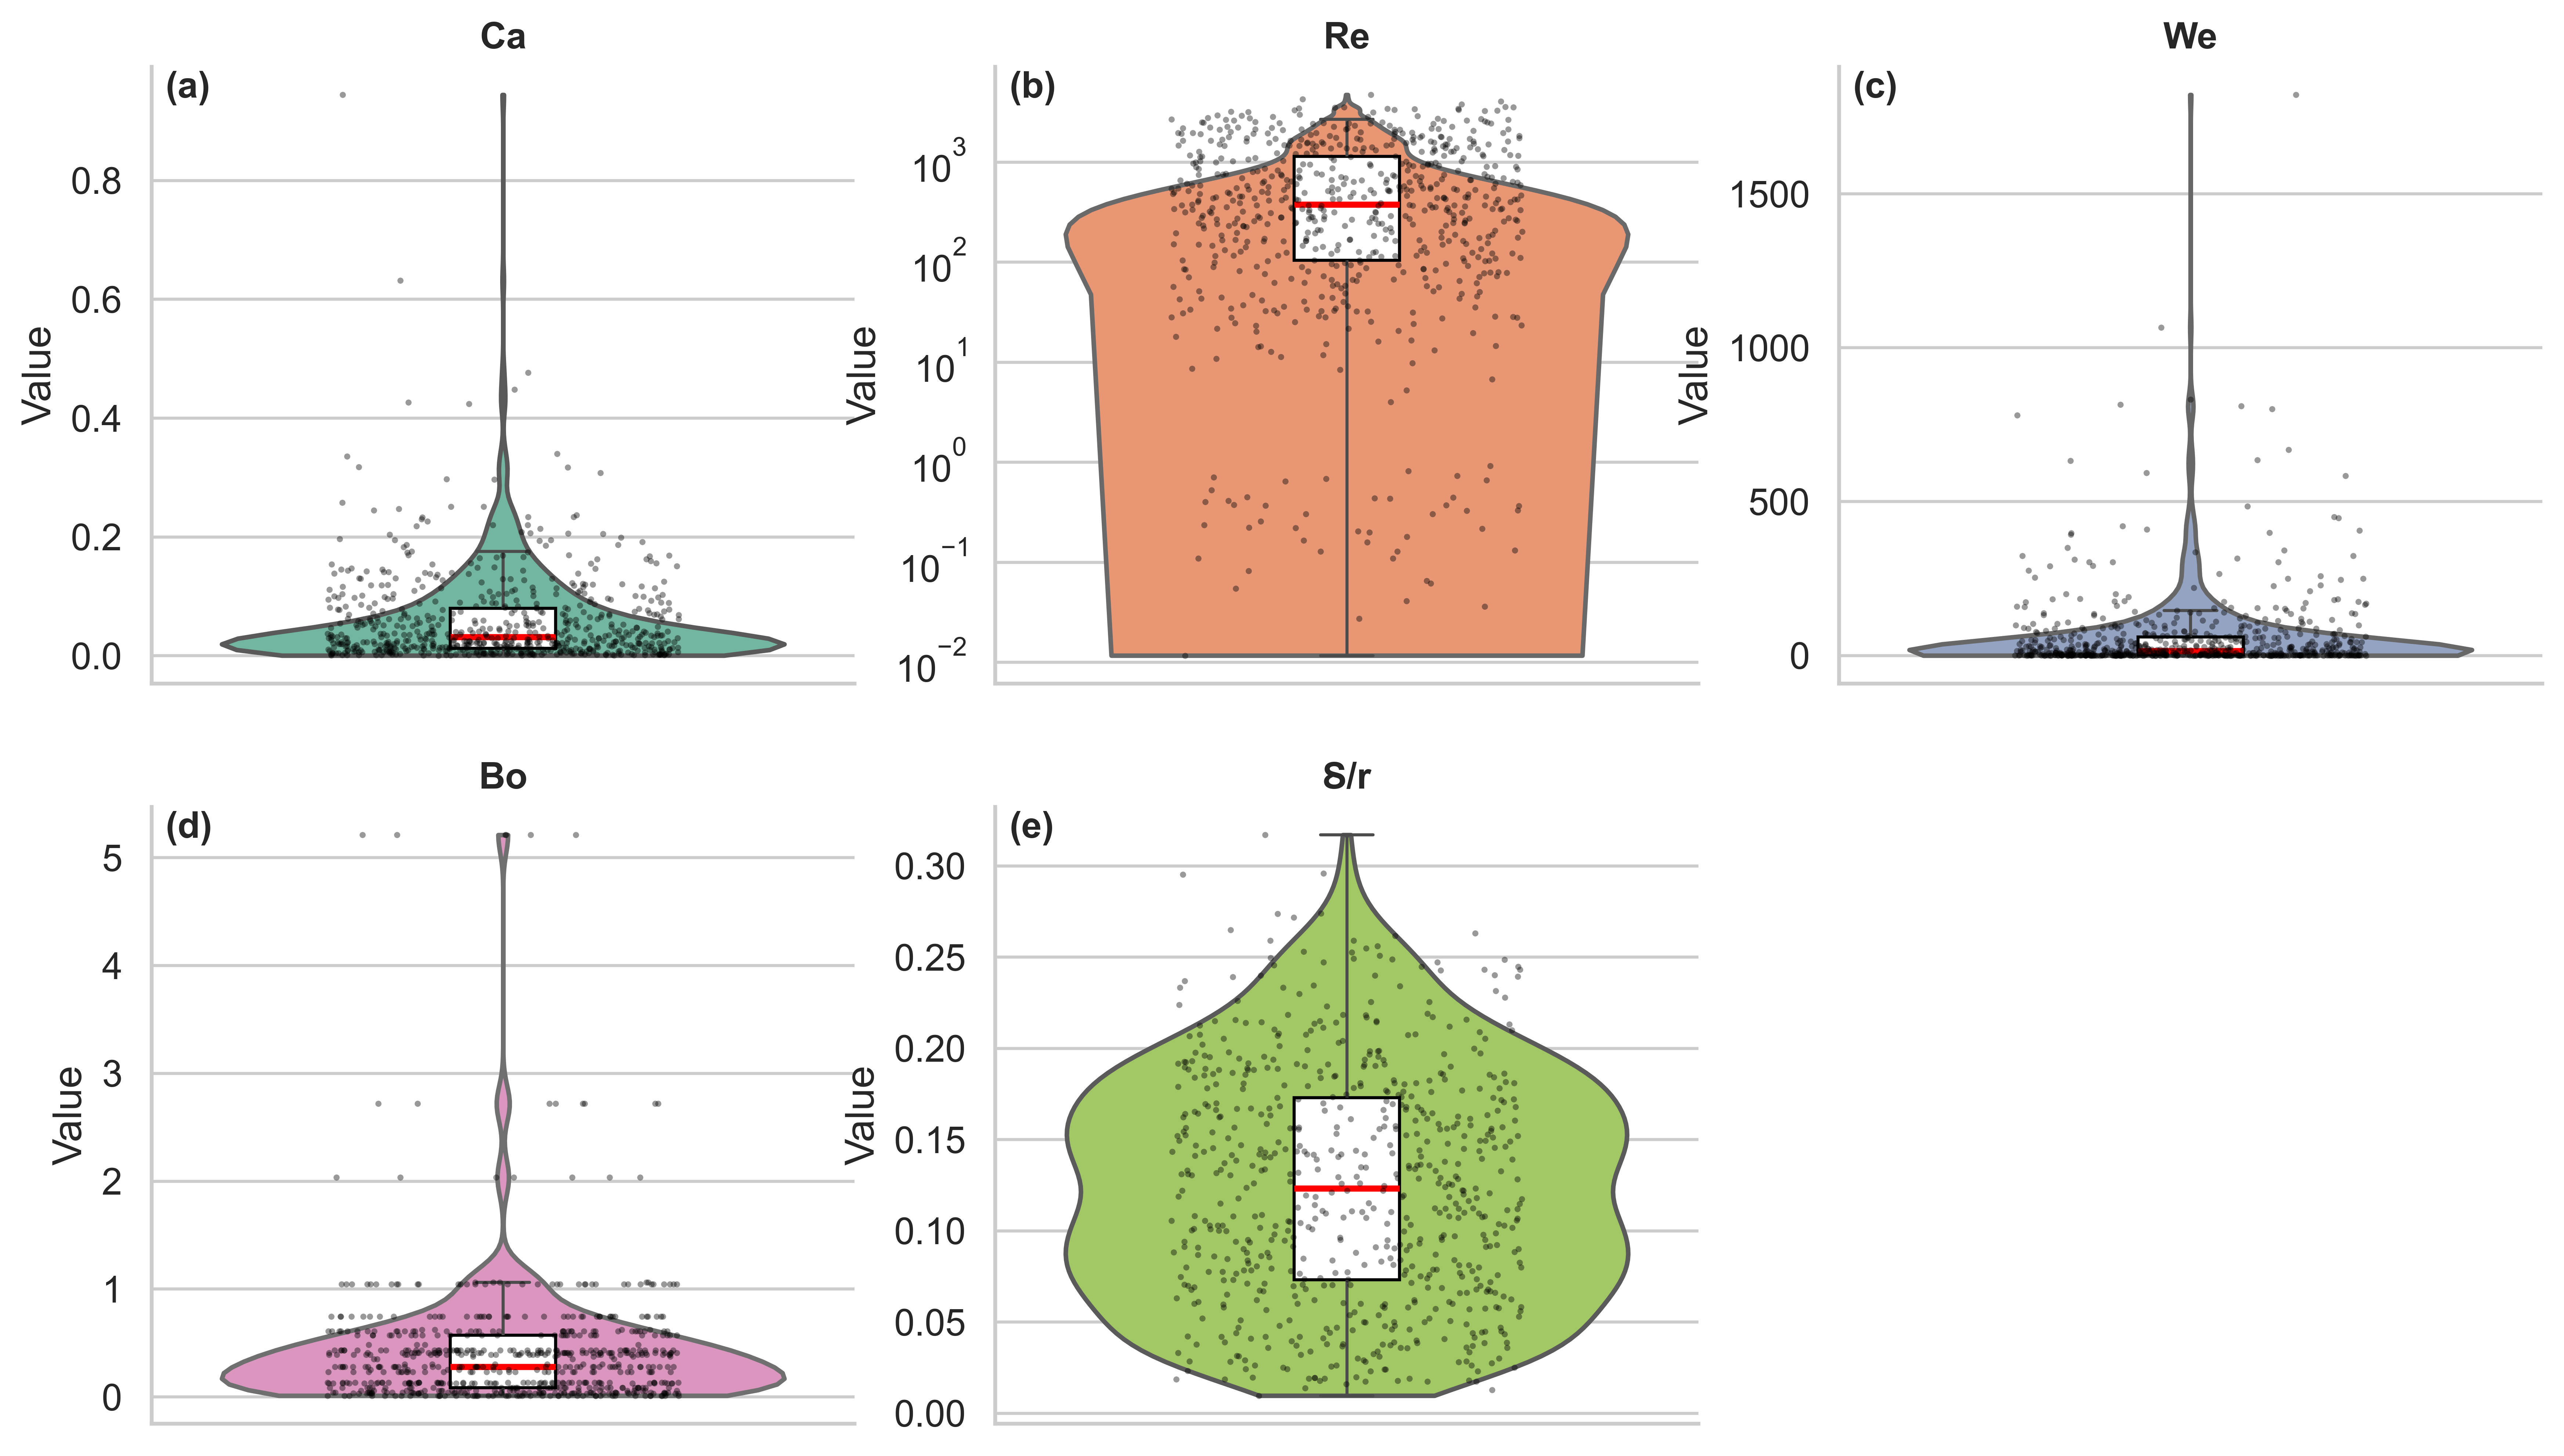

Figure saved to: C:\Users\verma\Desktop\PC\Updated\Plots_with outliers\vilon_plot.png


In [7]:
# 5. Visualize data distributions
sns.set(style="whitegrid", font_scale=1.1)

features = ['Ca', 'Re', 'We', 'Bo', 'Ꟙ/r']
palette = sns.color_palette("Set2", len(features))

# Create figure (2 rows × 3 columns)
fig = plt.figure(figsize=(14, 8), dpi=600)

# ----------------------------
# Subplots for violin plots
# ----------------------------
for i, col in enumerate(features):

    ax = plt.subplot(2, 3, i + 1)

    # Violin plot
    sns.violinplot(
        y=data[col],
        ax=ax,
        color=palette[i],
        inner=None,
        linewidth=1.5,
        cut=0
    )

    # Box plot
    sns.boxplot(
        y=data[col],
        ax=ax,
        width=0.15,
        boxprops=dict(facecolor="white", edgecolor="black"),
        medianprops=dict(color="red", linewidth=2),
        showfliers=False
    )

    # Scatter plot
    sns.stripplot(
        y=data[col],
        ax=ax,
        color="black",
        size=2,
        jitter=0.25,
        alpha=0.4
    )

    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel("Value")

    # Subplot labels (a-e)
    ax.text(
        0.02, 0.95,
        f"({chr(97+i)})",
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold'
    )

    # Log scale for Reynolds number
    if col == 'Re':
        ax.set_yscale('log')

    sns.despine(ax=ax)

# Save figure
save_path = os.path.join(r"C:\Users\verma\Desktop\PC\Updated\Plots_with outliers", "vilon_plot.png")
plt.savefig(
    save_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Figure saved to: {save_path}")

           Ca        Re        We        Bo       Ꟙ/r
Ca   1.000000  0.223875  0.755085 -0.021603  0.713165
Re   0.223875  1.000000  0.571990 -0.219626  0.533160
We   0.755085  0.571990  1.000000 -0.044520  0.590366
Bo  -0.021603 -0.219626 -0.044520  1.000000 -0.091540
Ꟙ/r  0.713165  0.533160  0.590366 -0.091540  1.000000




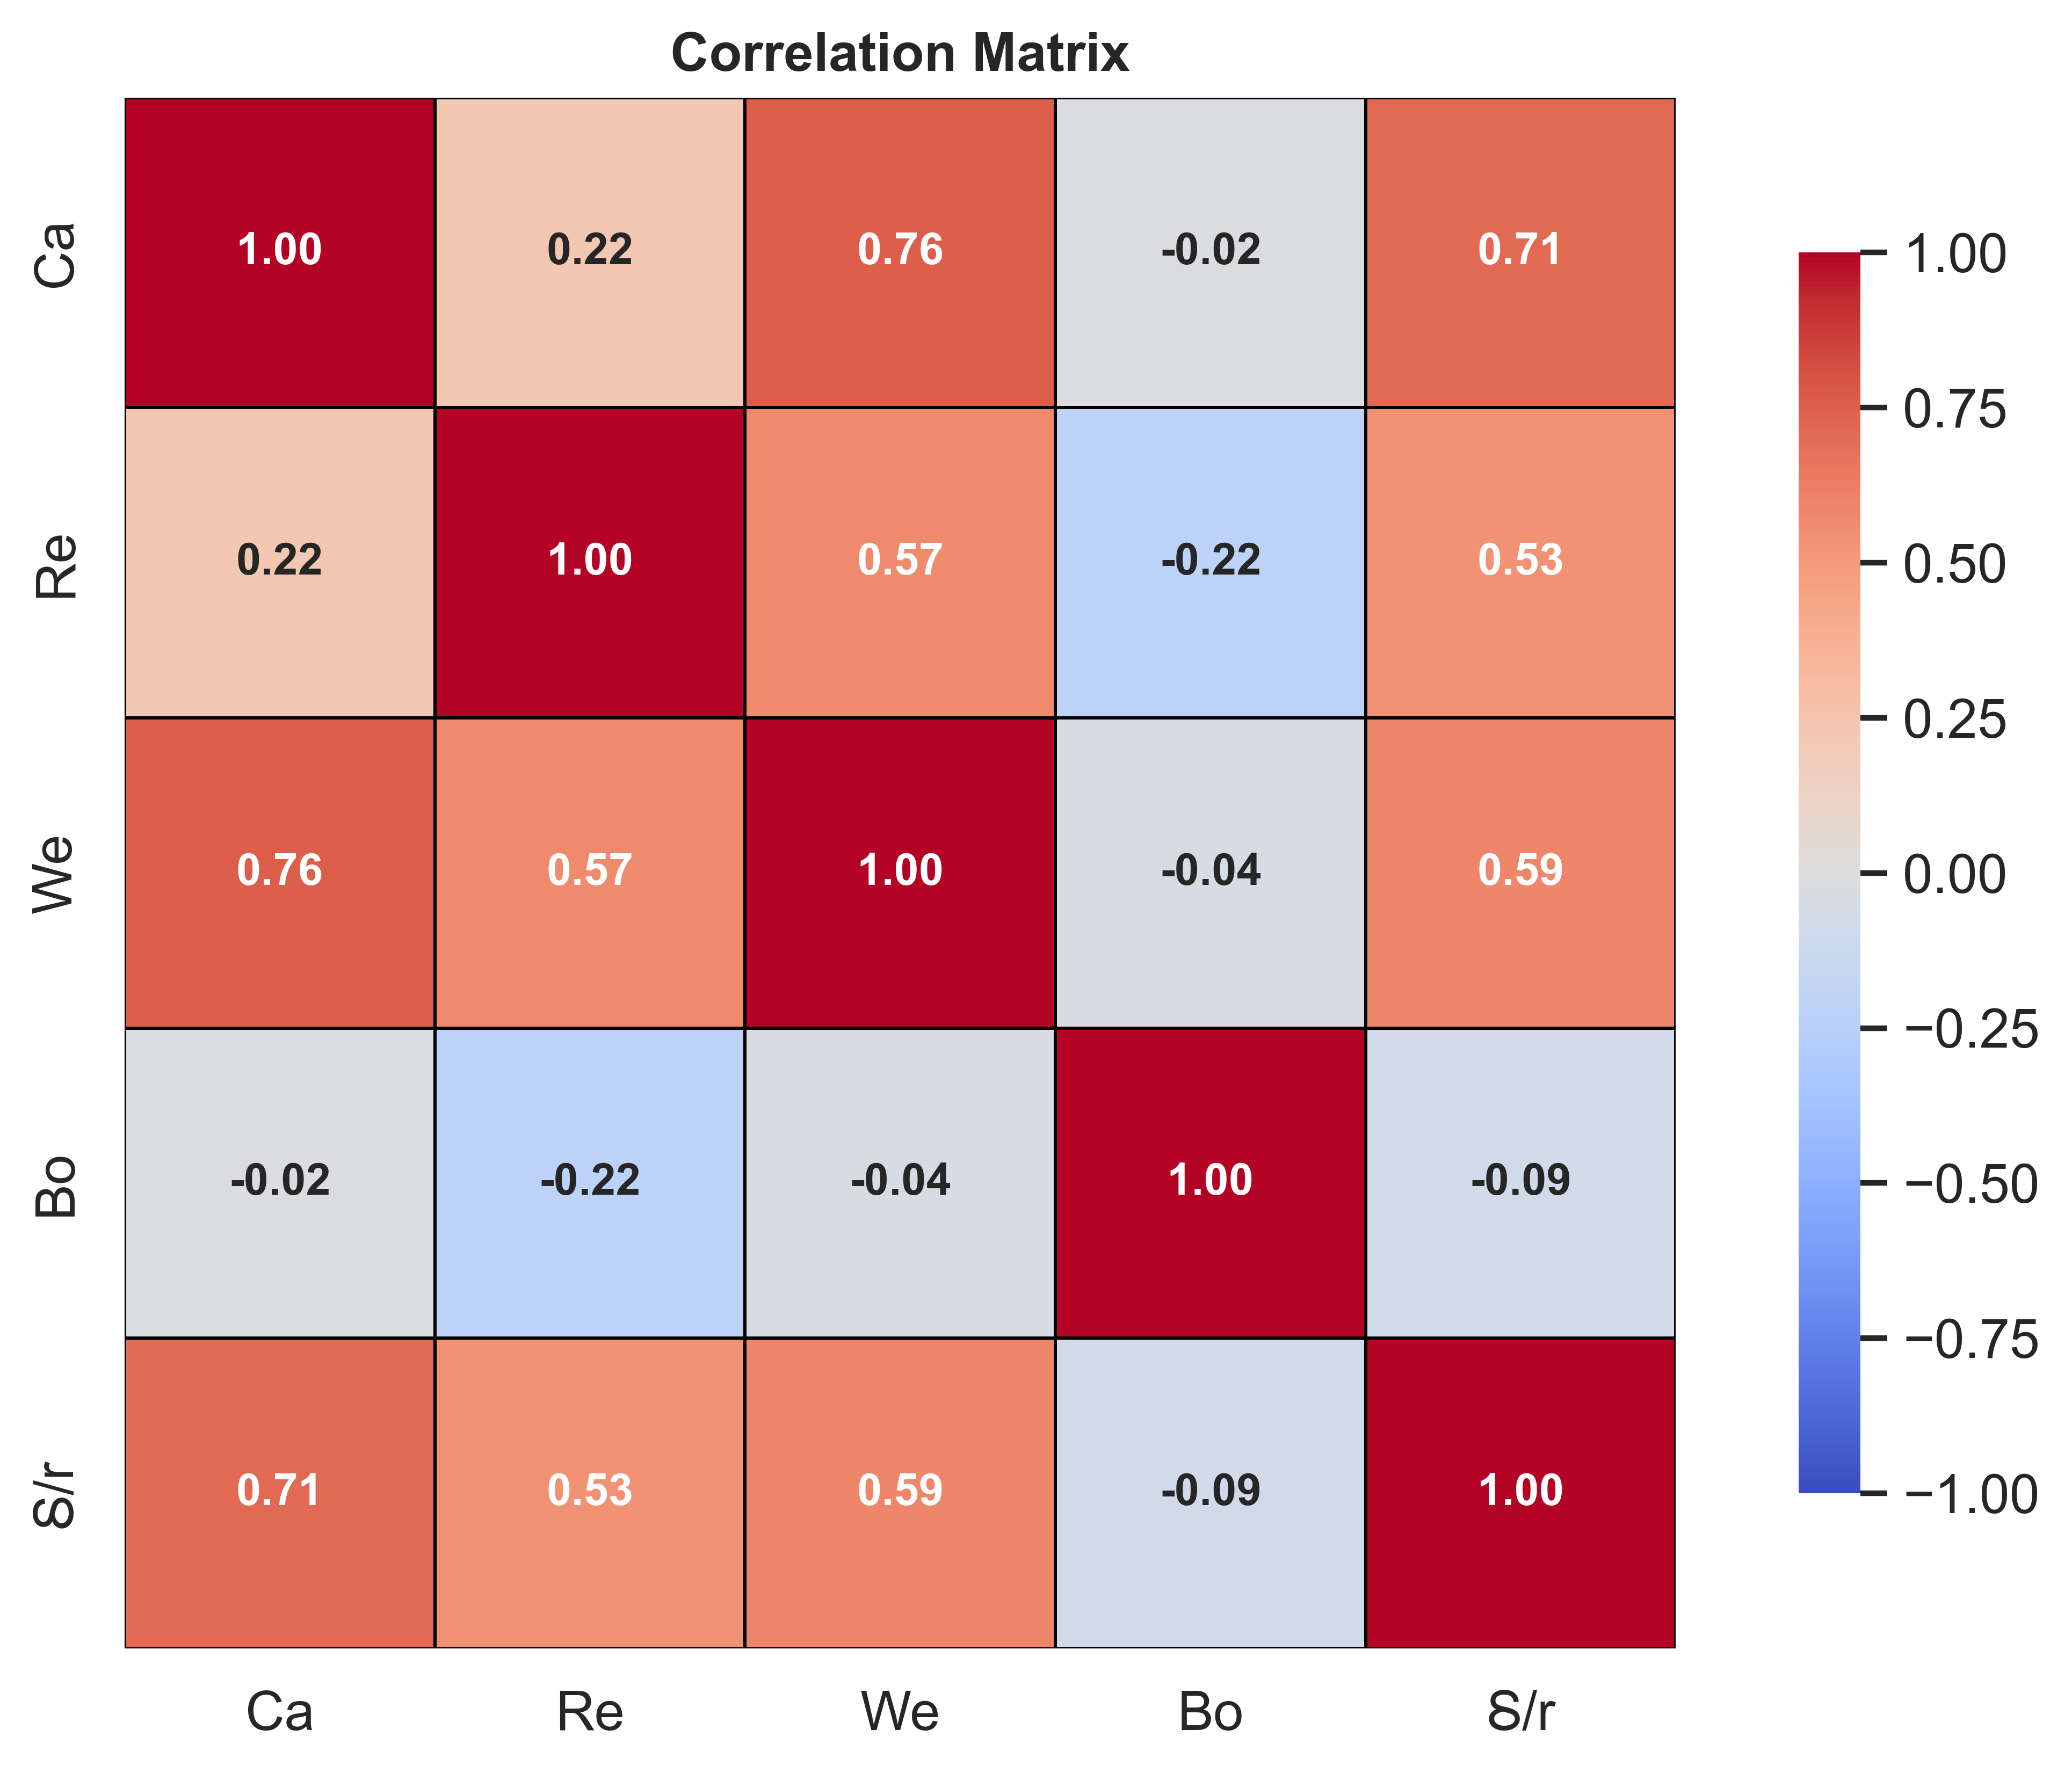

In [8]:
# 6. Correlation matrix
# ----------------------------
corr = data[features].corr()

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6), dpi=600)

sns.heatmap(
    corr,
    annot=True,                 # Show correlation values
    cmap="coolwarm",
    fmt=".2f",                  # Display 2 decimal places
    linewidths=0.5,
    linecolor='black',
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 10, "weight": "bold"},
    ax=ax
)

ax.set_title(
    "Correlation Matrix",
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

#Save
save_path = r"C:\Users\verma\Desktop\PC\Updated\Plots_with outliers\correlation_matrix1.png"

fig.savefig(
    save_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

print(corr)          # Prints the full correlation matrix in the console
print("\n")

plt.show()

In [9]:
# 7. Define features & target
X = data.drop(columns=["Bo", "Ꟙ/r"])   # Droping column Bo least correlation
y = data["Ꟙ/r"]
print('training shape:',X.shape)
print('testing shape:',y.shape)

training shape: (669, 3)
testing shape: (669,)


In [10]:
# 8. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('training shape:',X_train.shape)
print('testing shape:',X_test.shape)

training shape: (535, 3)
testing shape: (134, 3)


In [11]:
# 9. Data Normalization
from sklearn.preprocessing import StandardScaler

# Standardization
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame (optional)
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

print("Training shape:", X_train_scaled.shape)
print("Testing shape :", X_test_scaled.shape)

Training shape: (535, 3)
Testing shape : (134, 3)


In [12]:
# OUTPUT DIRECTORY
OUTPUT_DIR = r"C:\Users\verma\Desktop\PC\Updated\Plots_with outliers"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Plots will be saved to:", OUTPUT_DIR)

# =============================================================================
# GLOBAL PLOT STYLE
# =============================================================================
plt.style.use('default')

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.weight'] = 'bold'

mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'

mpl.rcParams['axes.edgecolor'] = 'black'
mpl.rcParams['axes.linewidth'] = 2.0

mpl.rcParams['xtick.color'] = 'black'
mpl.rcParams['ytick.color'] = 'black'

mpl.rcParams['xtick.major.width'] = 2.0
mpl.rcParams['ytick.major.width'] = 2.0

mpl.rcParams['text.color'] = 'black'
mpl.rcParams['axes.labelcolor'] = 'black'

mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'

mpl.rcParams['axes.grid'] = False

def apply_journal_style(ax):

    # Make all ticks bold
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_fontfamily('Arial')
        label.set_color('black')

    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontfamily('Arial')
        label.set_color('black')

    # Axis labels
    ax.xaxis.label.set_fontweight('bold')
    ax.yaxis.label.set_fontweight('bold')

    # Title
    ax.title.set_fontweight('bold')

    # Black border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(2.0)

    ax.grid(False)
# =============================================================================
# REGRESSION PLOT
# =============================================================================
features = ['Ca', 'Re', 'We']
def regression_plot(
        y_train,
        y_train_pred,
        y_test,
        y_test_pred,
        model_name):

    plt.rcParams['font.family'] = 'Arial'

    fig, ax = plt.subplots(
        figsize=(7, 7),
        dpi=600
    )
    ax.set_facecolor('white')
    ax.grid(False)

    # --------------------------------------------------
    # Combine train and test
    # --------------------------------------------------
    all_actual = np.concatenate([y_train, y_test])
    all_pred = np.concatenate([y_train_pred, y_test_pred])

    # --------------------------------------------------
    # Scatter points
    # --------------------------------------------------
    ax.scatter(
        y_train,
        y_train_pred,
        c="#8E44AD",
        s=55,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.4,
        label=f"Train" # f"Train (n={len(y_train)})"
    )

    ax.scatter(
        y_test,
        y_test_pred,
        c="#2980B9",
        s=55,
        alpha=0.80,
        edgecolors="black",
        linewidths=0.4,
        label=f"Test" #f"Test (n={len(y_test)})"
    )

    # --------------------------------------------------
    # Limits
    # --------------------------------------------------
    mn = min(all_actual.min(), all_pred.min())
    mx = max(all_actual.max(), all_pred.max())

    padding = (mx - mn) * 0.05

    mx += padding
    mn = 0.0

    # --------------------------------------------------
    # 1:1 line
    # --------------------------------------------------
    ax.plot(
        [mn, mx],
        [mn, mx],
        '--',
        color='dimgray',
        linewidth=1.5,
        #label='1:1 Line'
    )

    # --------------------------------------------------
    # Regression line
    # --------------------------------------------------
    slope, intercept, r_value, p_value, std_err = linregress(
        all_actual,
        all_pred
    )

    x_line = np.linspace(mn, mx, 100)
    y_line = intercept + slope * x_line

    ax.plot(
        x_line,
        y_line,
        color='red',
        linewidth=2,
        #label='Regression Line'
    )

    # --------------------------------------------------
    # Metrics
    # --------------------------------------------------
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_test_pred
        )
    )

    mae = mean_absolute_error(
        y_test,
        y_test_pred
    )

    bias = np.mean(
        y_test_pred - y_test
    )

    r = np.corrcoef(
        all_actual,
        all_pred
    )[0, 1]

    metrics_text = (
        f"Train R² = {r2_train:.3f}\n"
        f"Test R² = {r2_test:.3f}\n"
        f"R = {r:.3f}\n"
        f"RMSE = {rmse:.3f}\n"
        #f"MAE = {mae:.3f}\n"
        #f"Bias = {bias:.3f}\n"
        f"y = {slope:.3f}x + {intercept:.3f}"
    )

    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        fontsize=11,
        fontweight='bold',
        fontfamily='Arial',
        va='top',
        bbox=dict(
            facecolor='white',
            edgecolor='black',
            linewidth=2.5,
            alpha=1.0,
            boxstyle='round,pad=0.5'
        )
    )

    # --------------------------------------------------
    # Labels
    # --------------------------------------------------
    ax.set_xlabel(
        "Observed Values Ꟙ/r ",
        fontsize=15,
        fontweight='bold',
        fontfamily='Arial'
    )

    ax.set_ylabel(
        "Predicted Values Ꟙ/r ",
        fontsize=15,
        fontweight='bold',
        fontfamily='Arial'
    )

    ax.set_title(
        model_name,
        fontsize=16,
        fontweight='bold',
        fontfamily='Arial',
        pad=12
    )


    # --------------------------------------------------
    # Tick styling
    # --------------------------------------------------
    ax.tick_params(
        axis='both',
        labelsize=13
    )

    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_fontfamily('Arial')

    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontfamily('Arial')

    # --------------------------------------------------
   # --------------------------------------------------
    # --------------------------------------------------
    # Axis limits
    # --------------------------------------------------
    ax.set_xlim(0.0, mx)
    ax.set_ylim(0.0, mx)

    # --------------------------------------------------
    # Tick interval
    # --------------------------------------------------
    tick_interval = 0.05

    x_ticks = np.arange(
        0.0,
        mx + tick_interval,
        tick_interval
    )

    ax.set_xticks(x_ticks)
    ax.set_yticks(x_ticks)

    # --------------------------------------------------
    # Tick styling
    # --------------------------------------------------
    ax.tick_params(
        axis='both',
        labelsize=13
    )

    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_fontfamily('Arial')

    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontfamily('Arial')

    # --------------------------------------------------
    # Equal scaling
    # --------------------------------------------------
    ax.set_aspect('equal')
    # --------------------------------------------------
# Outer border (plot frame)
# --------------------------------------------------
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(2.5)

    # --------------------------------------------------
    # Legend
    # --------------------------------------------------
    legend = ax.legend(
        fontsize=11,
        frameon=True,
        loc='lower right'
    )

    for text in legend.get_texts():
        text.set_fontweight('bold')
        text.set_fontfamily('Arial')

    # --------------------------------------------------
    # Save figure
    # --------------------------------------------------
    apply_journal_style(ax)
    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"{model_name}_Regression1.png"
        ),
        dpi=600,
        bbox_inches='tight'
    )

    plt.show()
    plt.close()

# =============================================================================
# FEATURE IMPORTANCE PLOT
# =============================================================================

def feature_importance_plot(
        model,
        feature_names,
        model_name,
        top_n=None):

    importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })

    importance = importance.sort_values(
        "Importance",
        ascending=True
    )

    if top_n:
        importance = importance.tail(top_n)

    # ----------------------------------
    # Plot settings
    # ----------------------------------
    plt.style.use('default')
    plt.rcParams['font.family'] = 'Arial'

    fig, ax = plt.subplots(
        figsize=(5, 3),
        dpi=600
    )
   # Remove grid
    # ----------------------------------
    ax.grid(False)
    # ----------------------------------
    # Bar plot
    # ----------------------------------
    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature",
        palette="viridis",
        ax=ax
    )

    # ----------------------------------
    # Bar labels
    # ----------------------------------
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            fontsize=7,
            padding=2,
            fontweight='bold'
        )

    # ----------------------------------
    # Title
    # ----------------------------------
    ax.set_title(
        "Feature Importance",
        fontsize=11,
        fontweight="bold",
        fontfamily="Arial",
        color="black"
    )

    # ----------------------------------
    # Axis labels
    # ----------------------------------
    ax.set_xlabel(
        "Importance Score",
        fontsize=10,
        fontweight='bold',
        fontfamily='Arial',
        color='black'
    )

    ax.set_ylabel(
        "",
        fontsize=10,
        fontweight='bold',
        fontfamily='Arial',
        color='black'
    )

    # ----------------------------------
    # Tick labels
    # ----------------------------------
    ax.tick_params(
        axis='x',
        labelsize=8,
        colors='black',
        width=1.5
    )

    ax.tick_params(
        axis='y',
        labelsize=8,
        colors='black',
        width=1.5
    )

    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_fontfamily('Arial')
        label.set_color('black')

    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontfamily('Arial')
        label.set_color('black')

    # ----------------------------------
    # ----------------------------------
    # Full black border
    # ----------------------------------
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(2.0)

    # ----------------------------------
    # White background
    # ----------------------------------
    ax.set_facecolor('white')

    # ----------------------------------
    # Layout
    # ----------------------------------
    apply_journal_style(ax)
    plt.tight_layout()

    # ----------------------------------
    # Save figure
    # ----------------------------------
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"{model_name}_Feature_Importance.png"
        ),
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()
# =============================================================================
# SHAP BEESWARM PLOT
# =============================================================================

def shap_beeswarm_plot(
        model,
        X,
        model_name,
        max_display=15):

    plt.rcParams['font.family'] = 'Arial'

    # ----------------------------------
    # SHAP values
    # ----------------------------------
    explainer = shap.Explainer(model)
    shap_values = explainer(X)

    # ----------------------------------
    # Beeswarm plot
    # ----------------------------------
    shap.summary_plot(
        shap_values,
        X,
        max_display=max_display,
        show=False
    )

    ax = plt.gca()

    # ----------------------------------
    # Bold Arial tick labels
    # ----------------------------------
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_fontfamily('Arial')

    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontfamily('Arial')

    # ----------------------------------
    # Bold Arial axis labels
    # ----------------------------------
    ax.xaxis.label.set_fontweight('bold')
    ax.yaxis.label.set_fontweight('bold')

    ax.xaxis.label.set_fontfamily('Arial')
    ax.yaxis.label.set_fontfamily('Arial')

    # ----------------------------------
    # Thicker axis borders
    # ----------------------------------
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    # ----------------------------------
    # Title
    # ----------------------------------
    plt.title(
        "SHAP Summary Plot",
        fontsize=16,
        fontweight='bold',
        fontfamily='Arial'
    )

    apply_journal_style(ax)

    plt.tight_layout()

    # ----------------------------------
    # Save figure
    # ----------------------------------
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"{model_name}_SHAP_Beeswarm.png"
        ),
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    return shap_values

# =============================================================================
# SHAP BAR PLOT
# =============================================================================

def shap_bar_plot(
        shap_values,
        X,
        model_name,
        max_display=15):

    plt.rcParams['font.family'] = 'Arial'

    # ----------------------------------
    # SHAP Bar Plot
    # ----------------------------------
    shap.summary_plot(
        shap_values,
        X,
        plot_type="bar",
        max_display=max_display,
        show=False
    )

    ax = plt.gca()

    # ----------------------------------
    # Bold Arial tick labels
    # ----------------------------------
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_fontfamily('Arial')

    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontfamily('Arial')

    # ----------------------------------
    # Bold Arial axis labels
    # ----------------------------------
    ax.xaxis.label.set_fontweight('bold')
    ax.yaxis.label.set_fontweight('bold')

    ax.xaxis.label.set_fontfamily('Arial')
    ax.yaxis.label.set_fontfamily('Arial')

    # ----------------------------------
    # Thicker axis borders
    # ----------------------------------
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    # ----------------------------------
    # Title
    # ----------------------------------
    plt.title(
        "Global SHAP Feature Importance",
        fontsize=16,
        fontweight='bold',
        fontfamily='Arial'
    )

    apply_journal_style(ax)
    plt.tight_layout()

    # ----------------------------------
    # Save figure
    # ----------------------------------
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"{model_name}_SHAP_Bar.png"
        ),
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

Plots will be saved to: C:\Users\verma\Desktop\PC\Updated\Plots_with outliers


In [13]:
# 10. Define models
# -------------------------------
models = {

    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.01,
        num_leaves=63,
        max_depth=10,
        min_child_samples=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        importance_type='gain',
        random_state=42
    ),

    "XGBoost": XGBRegressor( 
        n_estimators=500
       #  learning_rate=0.01,
       #  max_depth=8,
       #  min_child_weight=3,
       #  subsample=0.8,
       #  colsample_bytree=0.8,
       #  gamma=0.1,
       #  reg_alpha=0.1,
       #  reg_lambda=1.0,
       #  objective='reg:squarederror',
       #  random_state=42,
       # n_jobs=-1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=500,
        learning_rate=0.01,
        depth=8,
        l2_leaf_reg=5,
        loss_function='RMSE',
        random_seed=42,
        verbose=100
    )
}
# -------------------------------

features = ['Ca', 'Re', 'We']
target = 'Ꟙ/r'


========== Random Forest ==========
R²   : 0.9129
MSE  : 0.0003
RMSE : 0.0186
MAPE : 0.1057


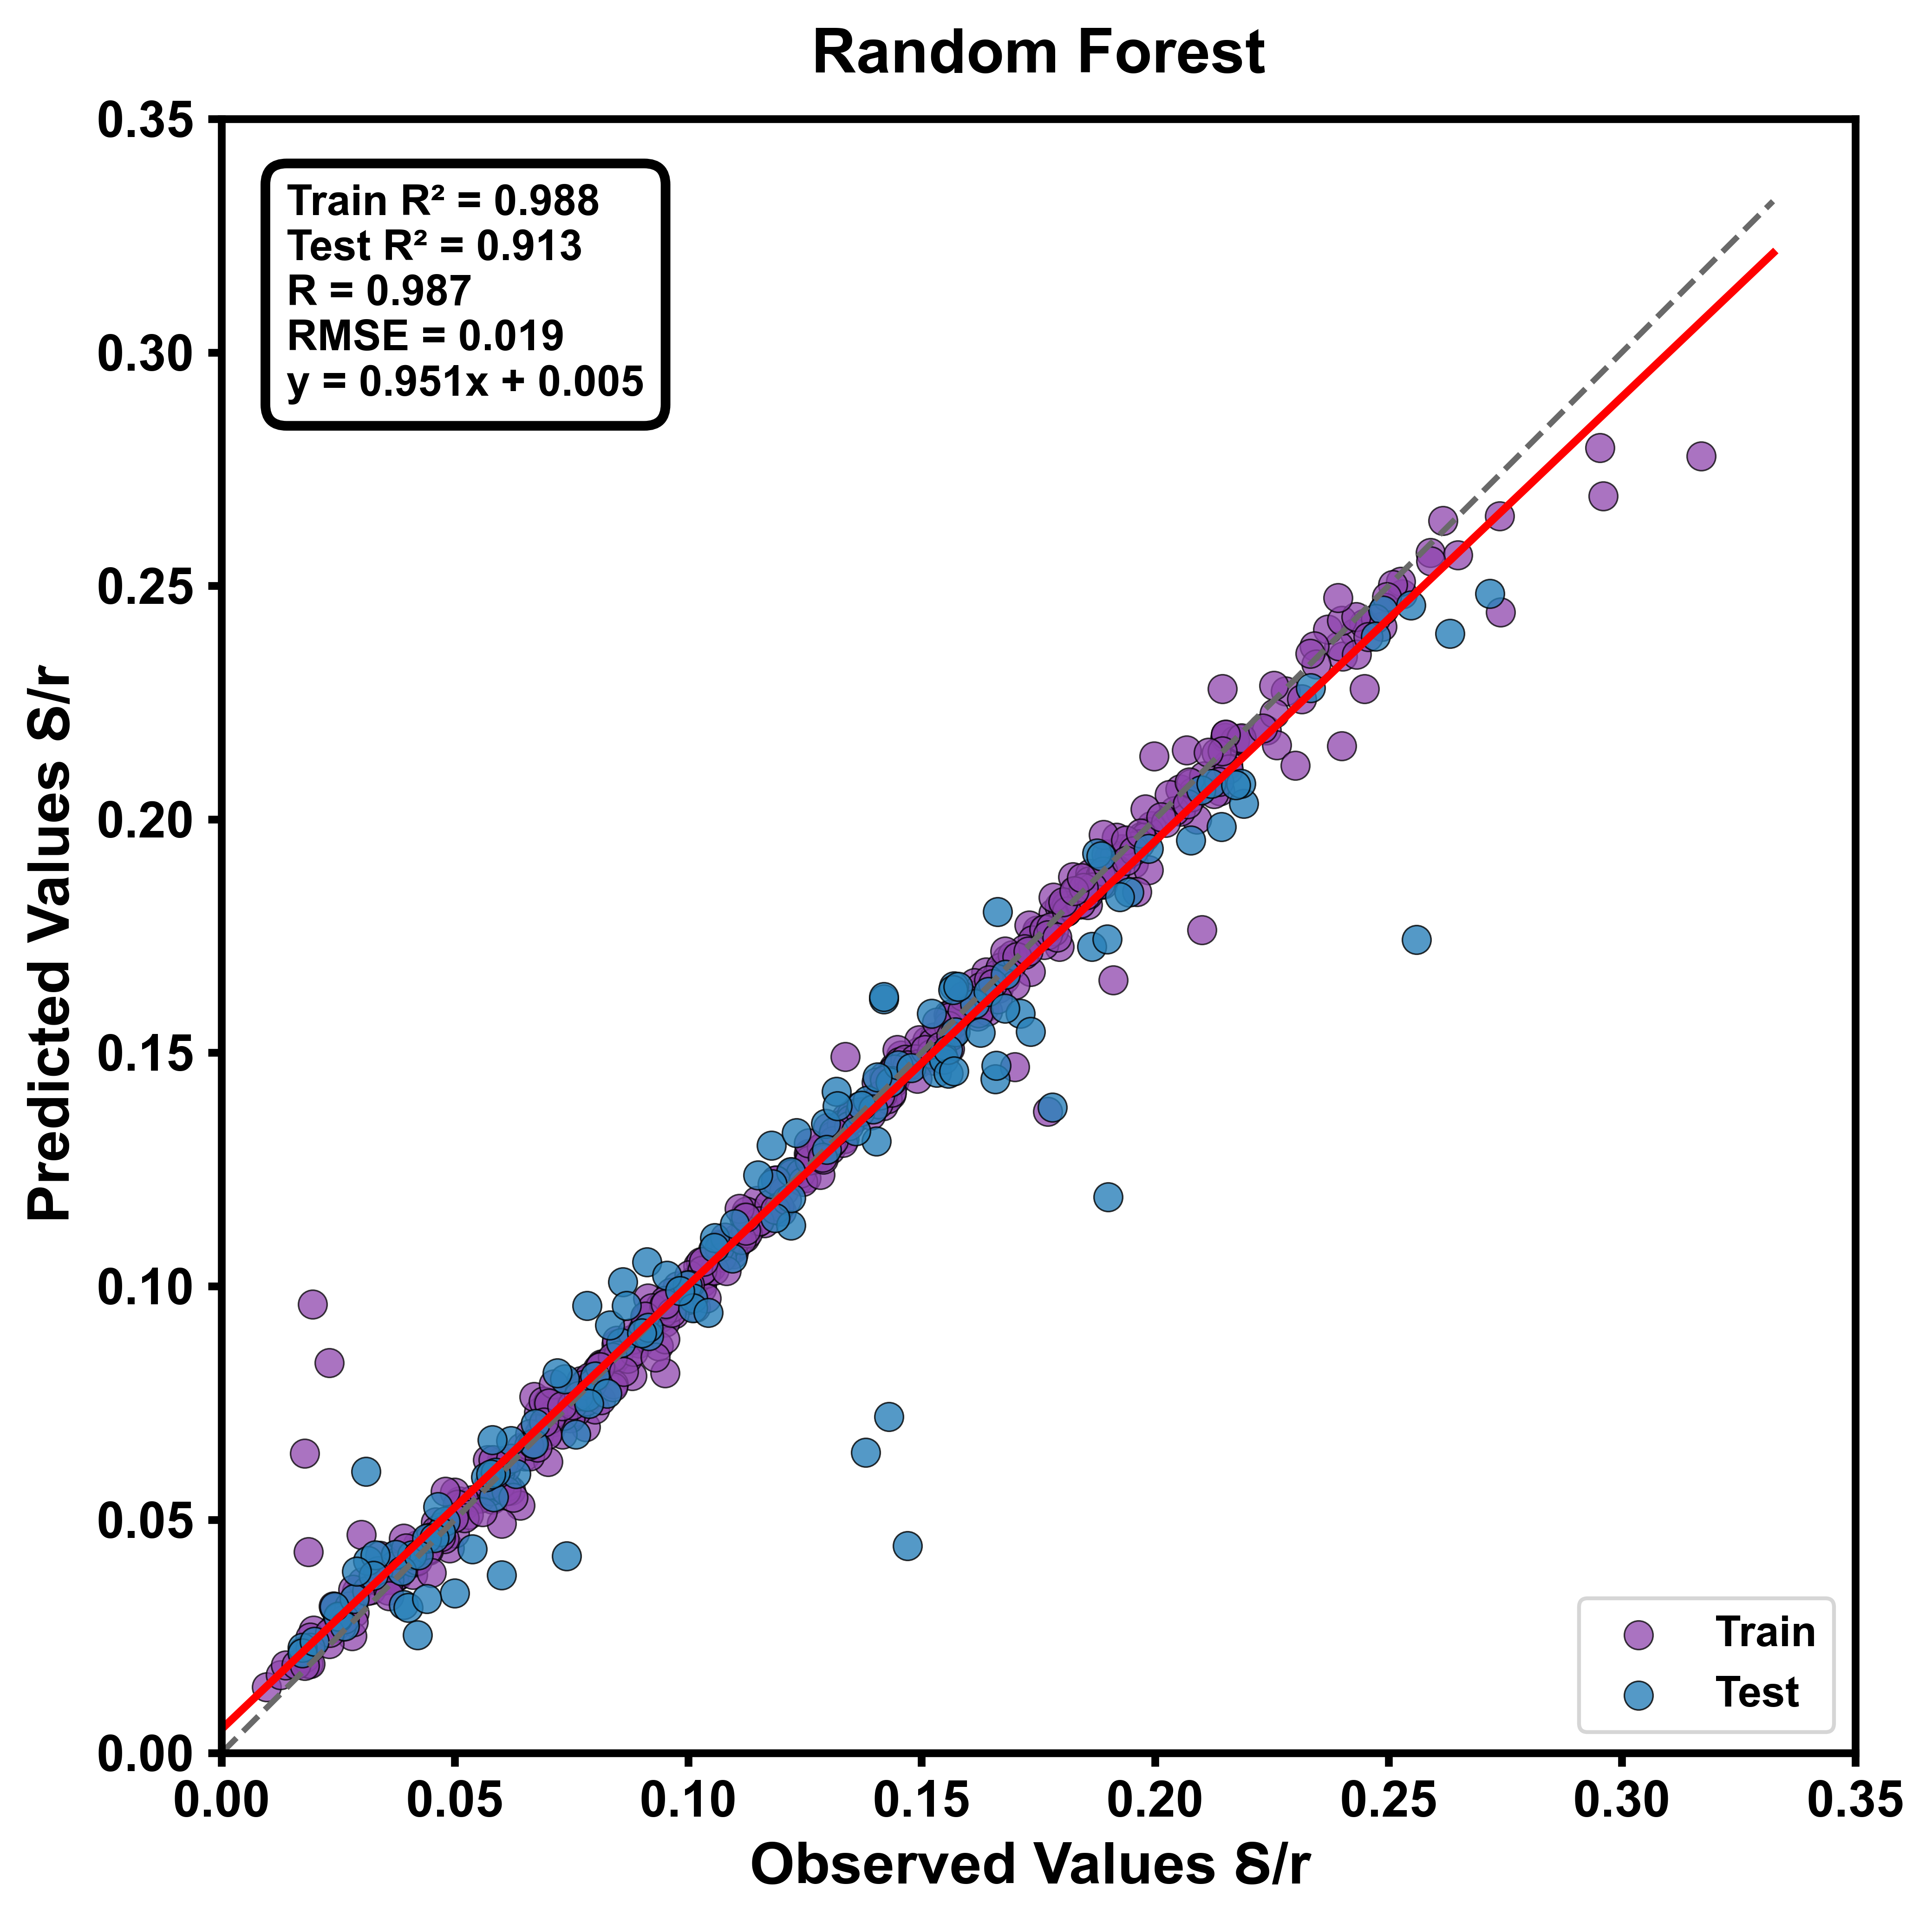


Feature Importance (%):
Ca    44.23
We    36.06
Re    19.72
dtype: float64


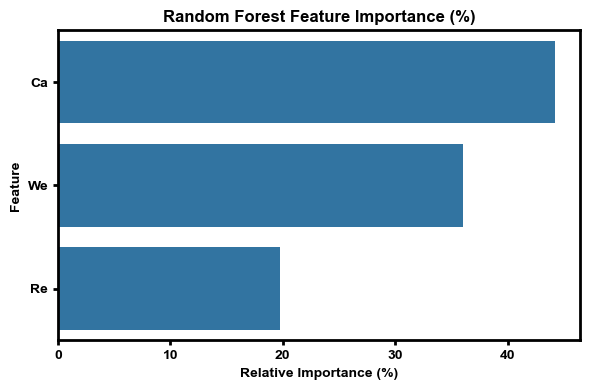


SHAP Analysis...


 97%|=================== | 130/134 [00:18<00:00]       

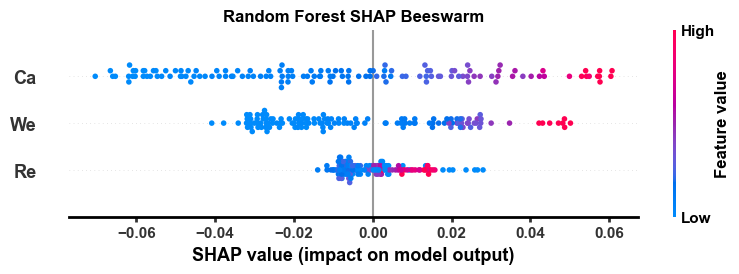

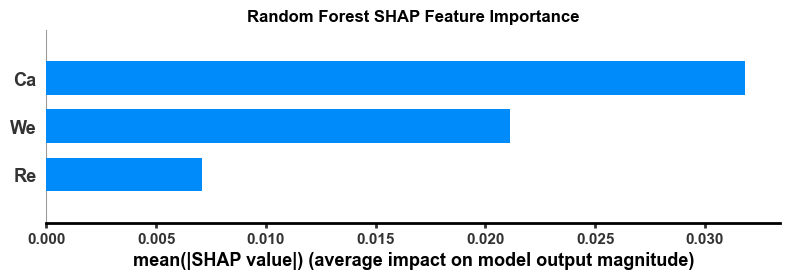


SHAP Feature Ranking:
Ca    0.031835
We    0.021130
Re    0.007092
dtype: float64

========== LightGBM ==========
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000684 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 537
[LightGBM] [Info] Number of data points in the train set: 535, number of used features: 3
[LightGBM] [Info] Start training from score 0.126592
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

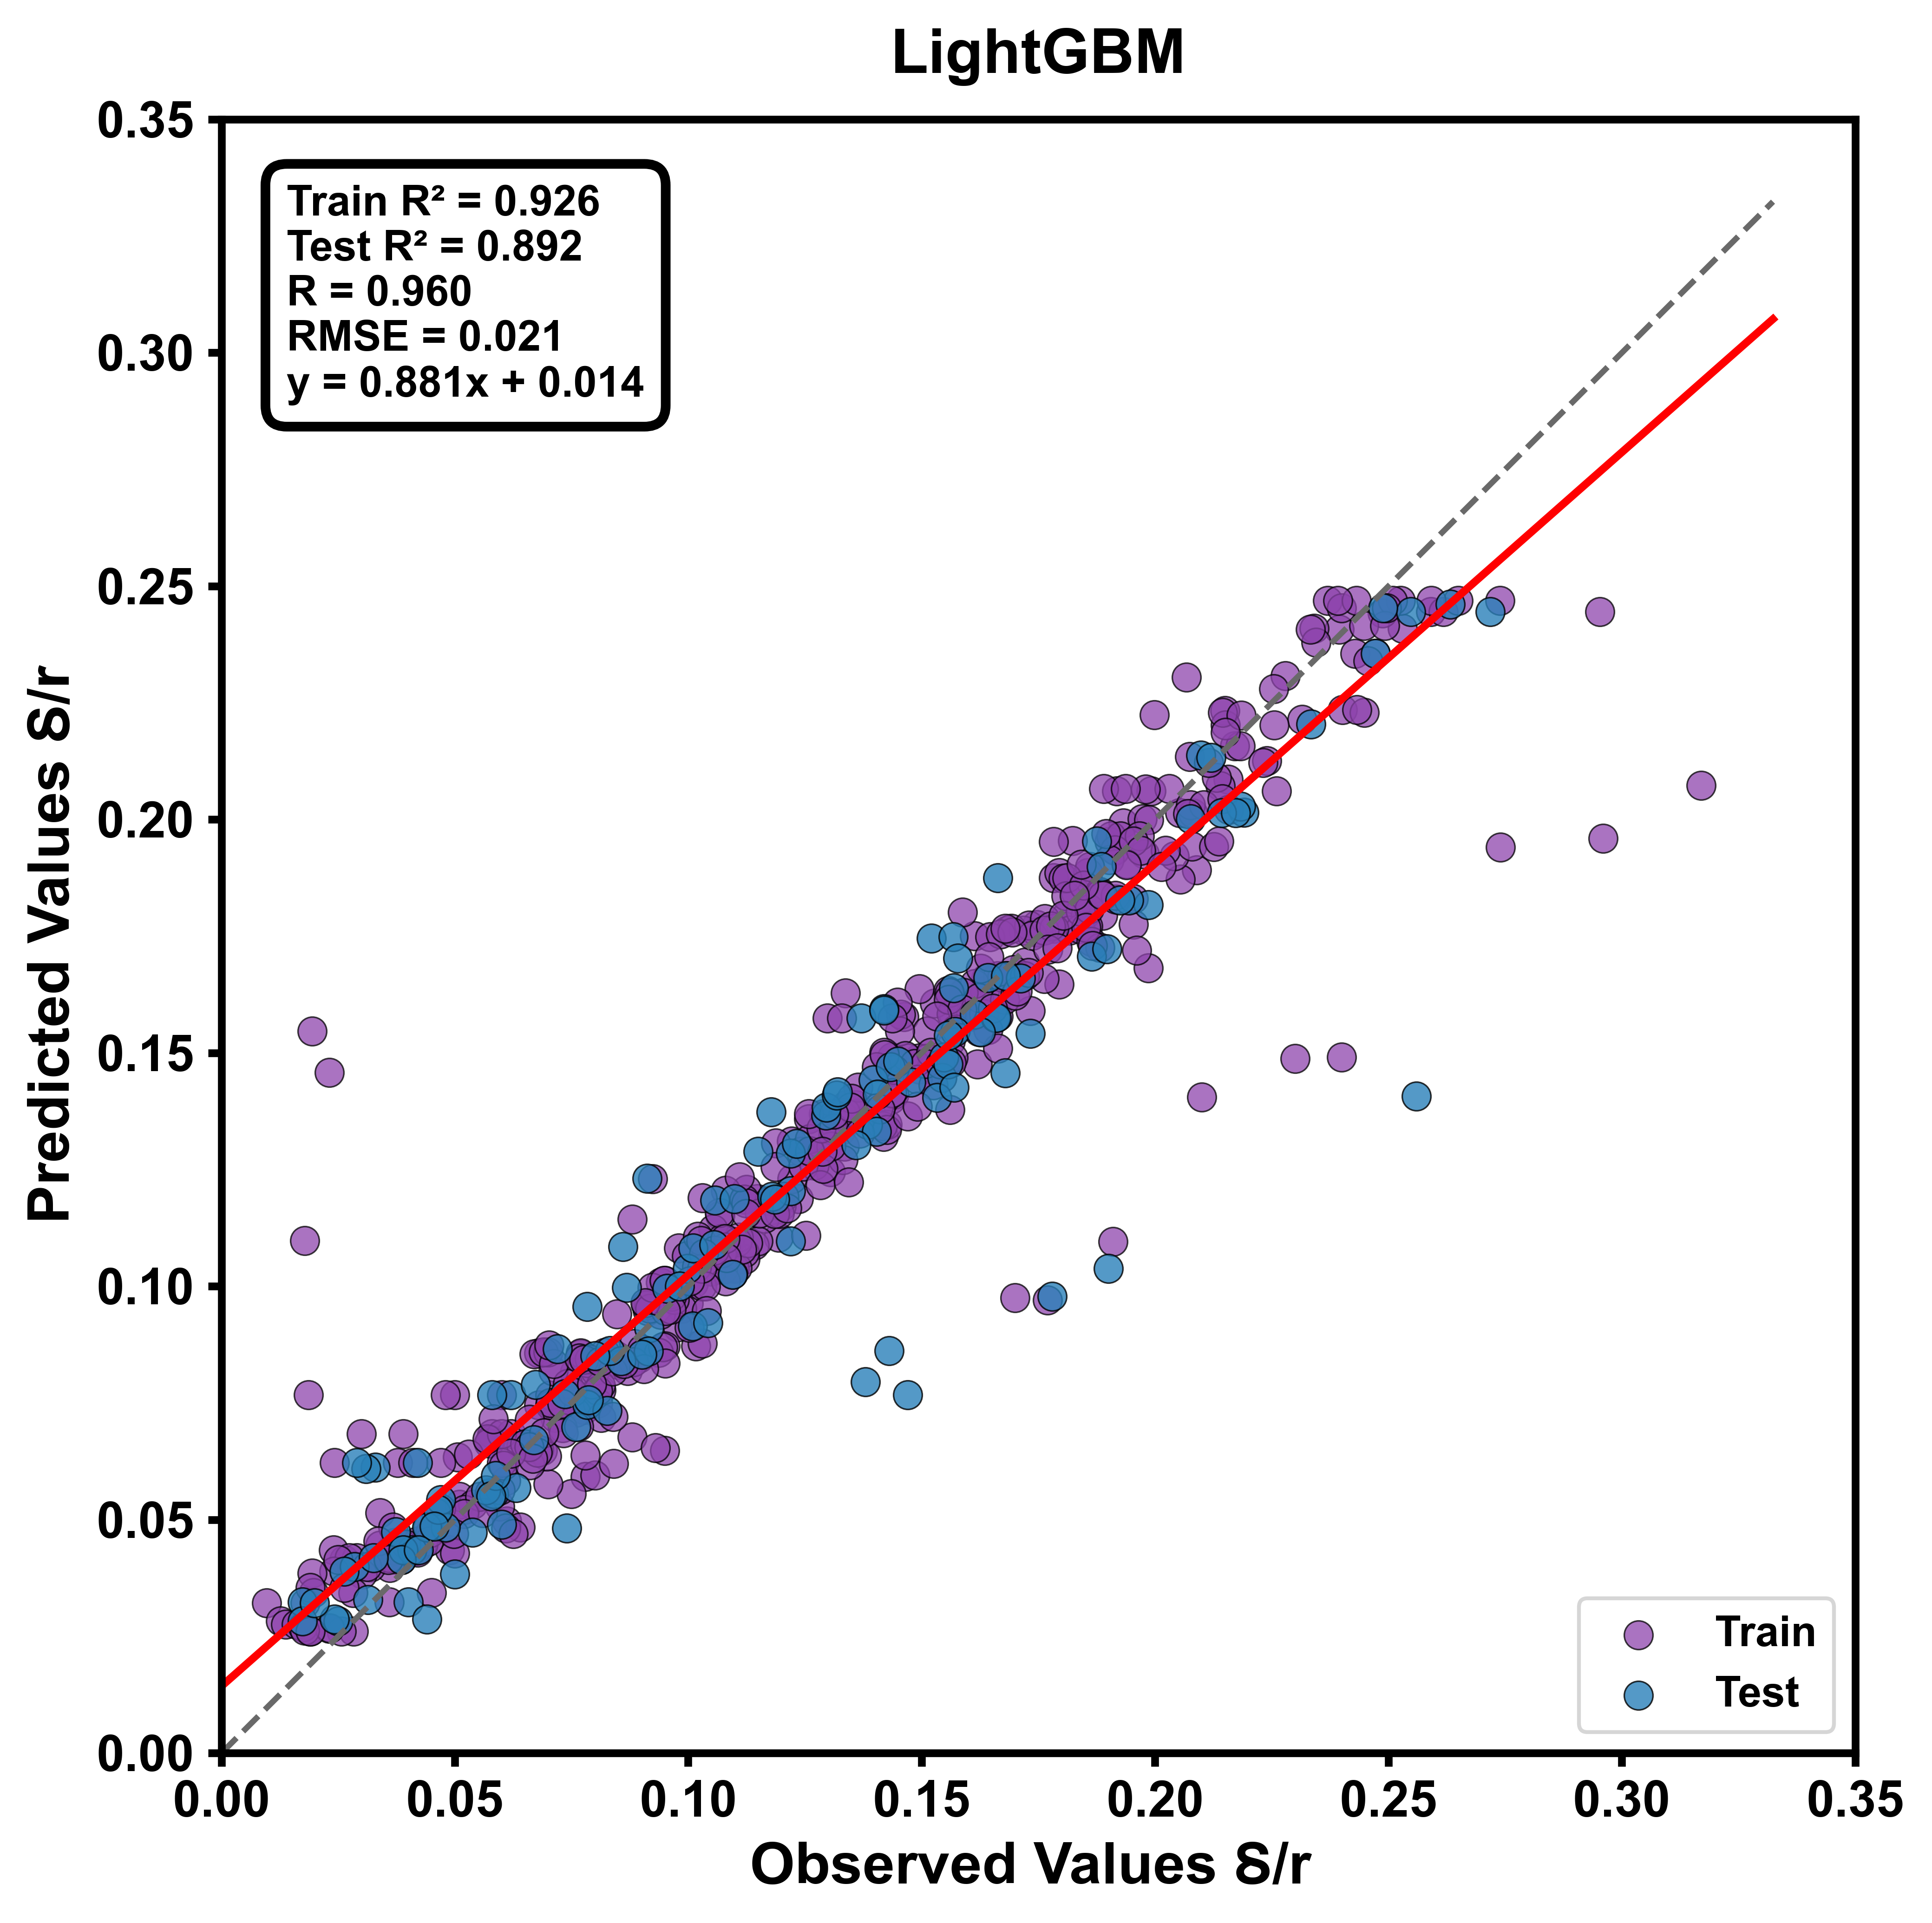


Feature Importance (%):
We    64.93
Ca    26.70
Re     8.38
dtype: float64


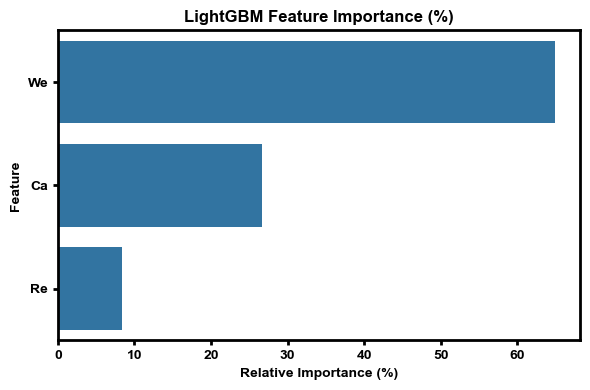


SHAP Analysis...


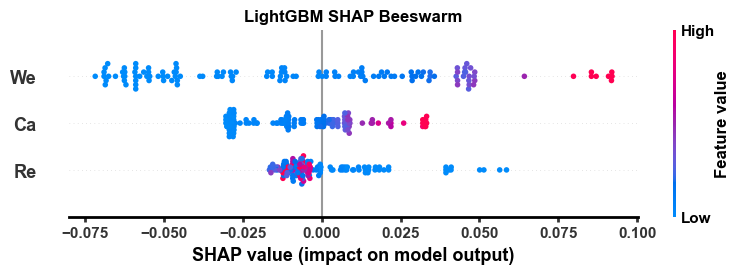

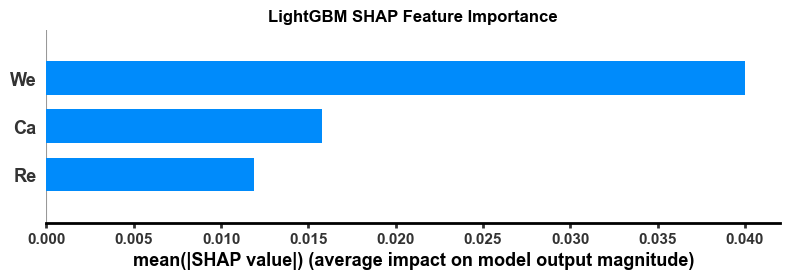


SHAP Feature Ranking:
We    0.040012
Ca    0.015782
Re    0.011914
dtype: float64

========== XGBoost ==========
R²   : 0.9278
MSE  : 0.0003
RMSE : 0.0169
MAPE : 0.0999


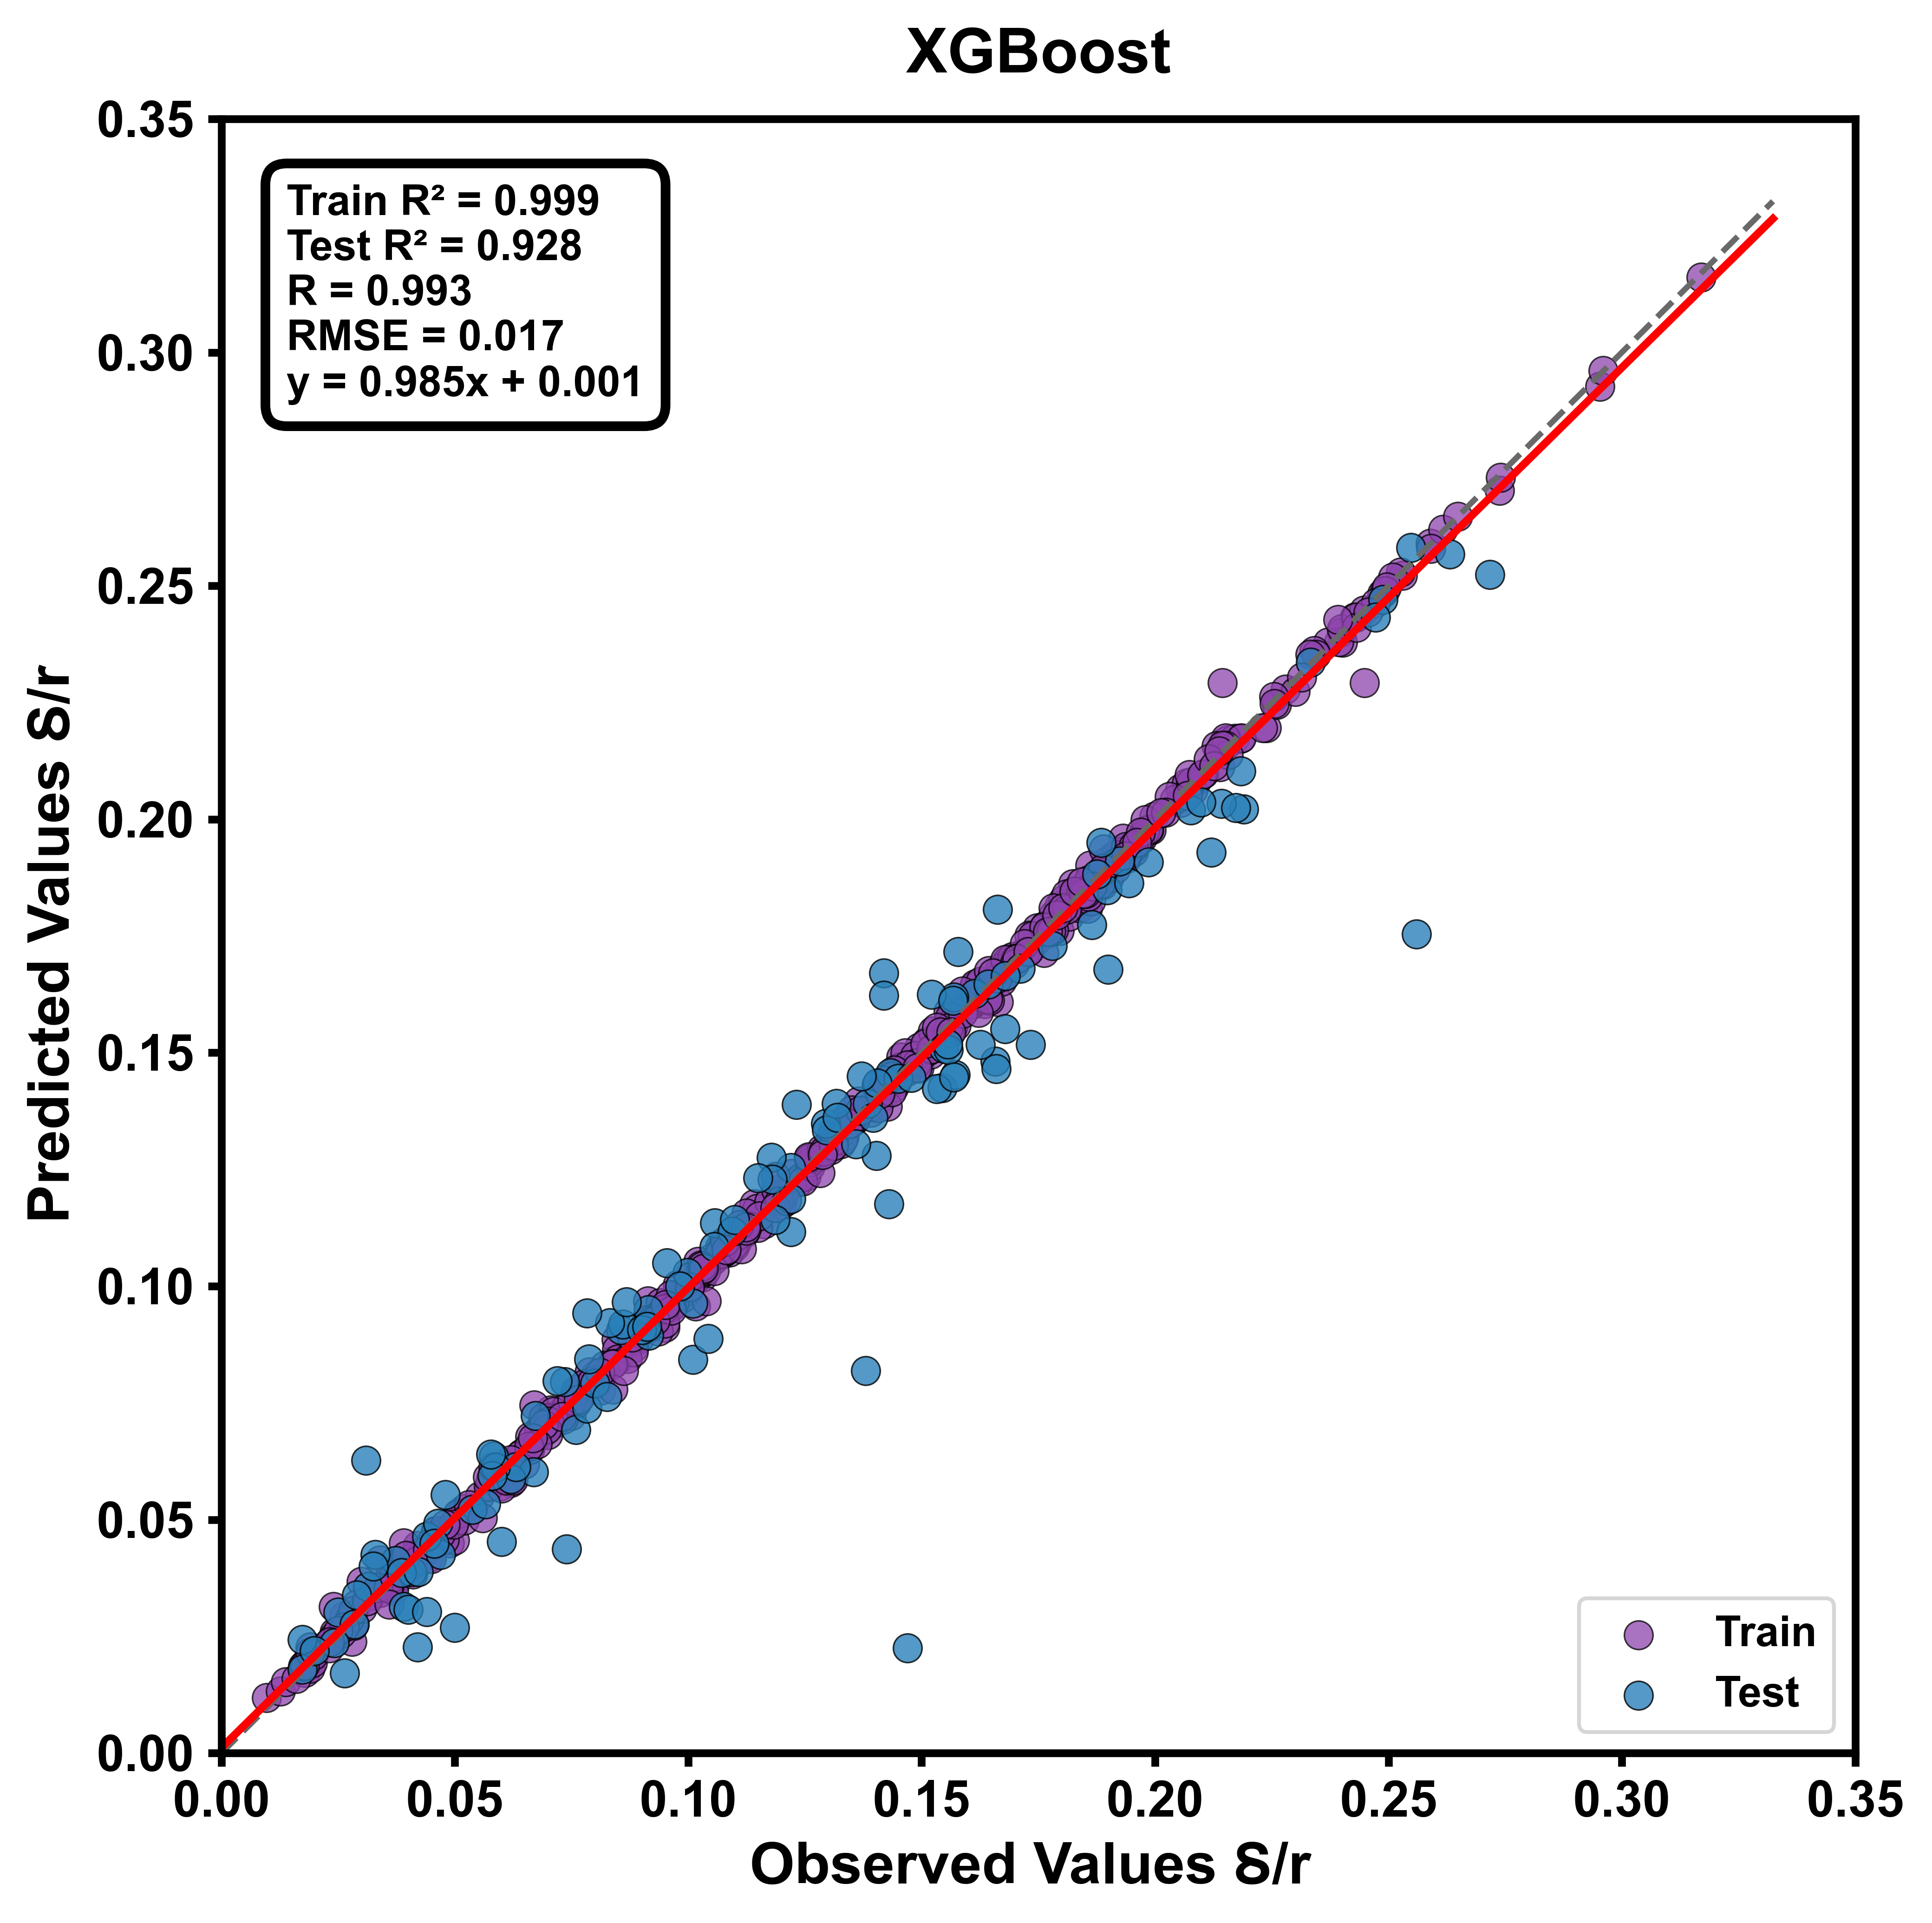


Feature Importance (%):
Ca    70.379997
We    24.040001
Re     5.580000
dtype: float32


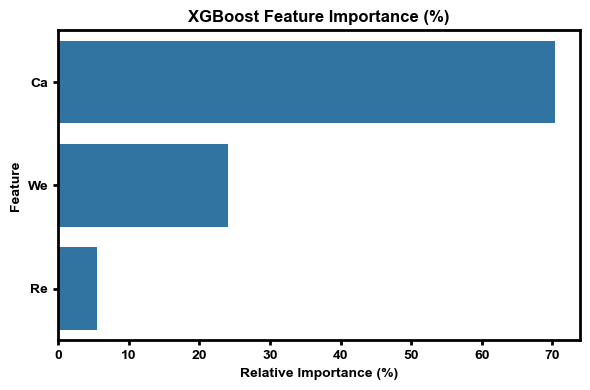


SHAP Analysis...


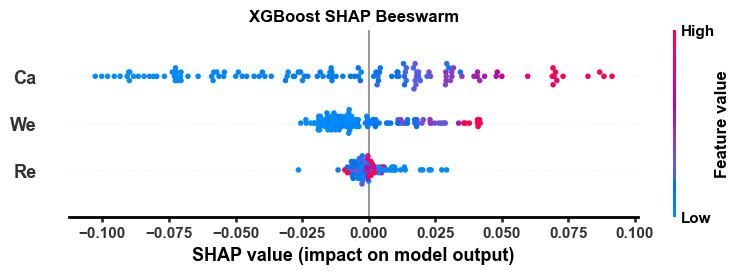

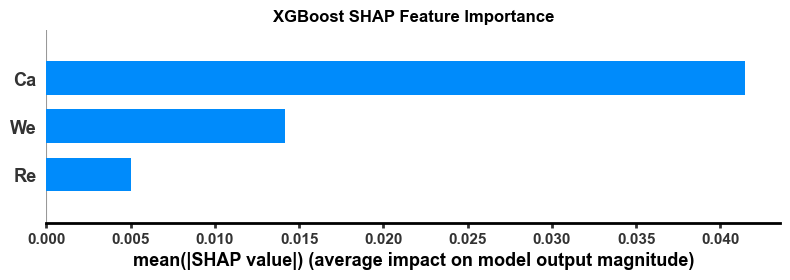


SHAP Feature Ranking:
Ca    0.041468
We    0.014165
Re    0.005036
dtype: float64

========== CatBoost ==========
0:	learn: 0.0636653	total: 247ms	remaining: 2m 3s
100:	learn: 0.0329203	total: 736ms	remaining: 2.91s
200:	learn: 0.0213959	total: 1.27s	remaining: 1.89s
300:	learn: 0.0166157	total: 1.76s	remaining: 1.16s
400:	learn: 0.0141641	total: 2.24s	remaining: 554ms
499:	learn: 0.0125080	total: 2.73s	remaining: 0us
R²   : 0.9282
MSE  : 0.0003
RMSE : 0.0168
MAPE : 0.1147


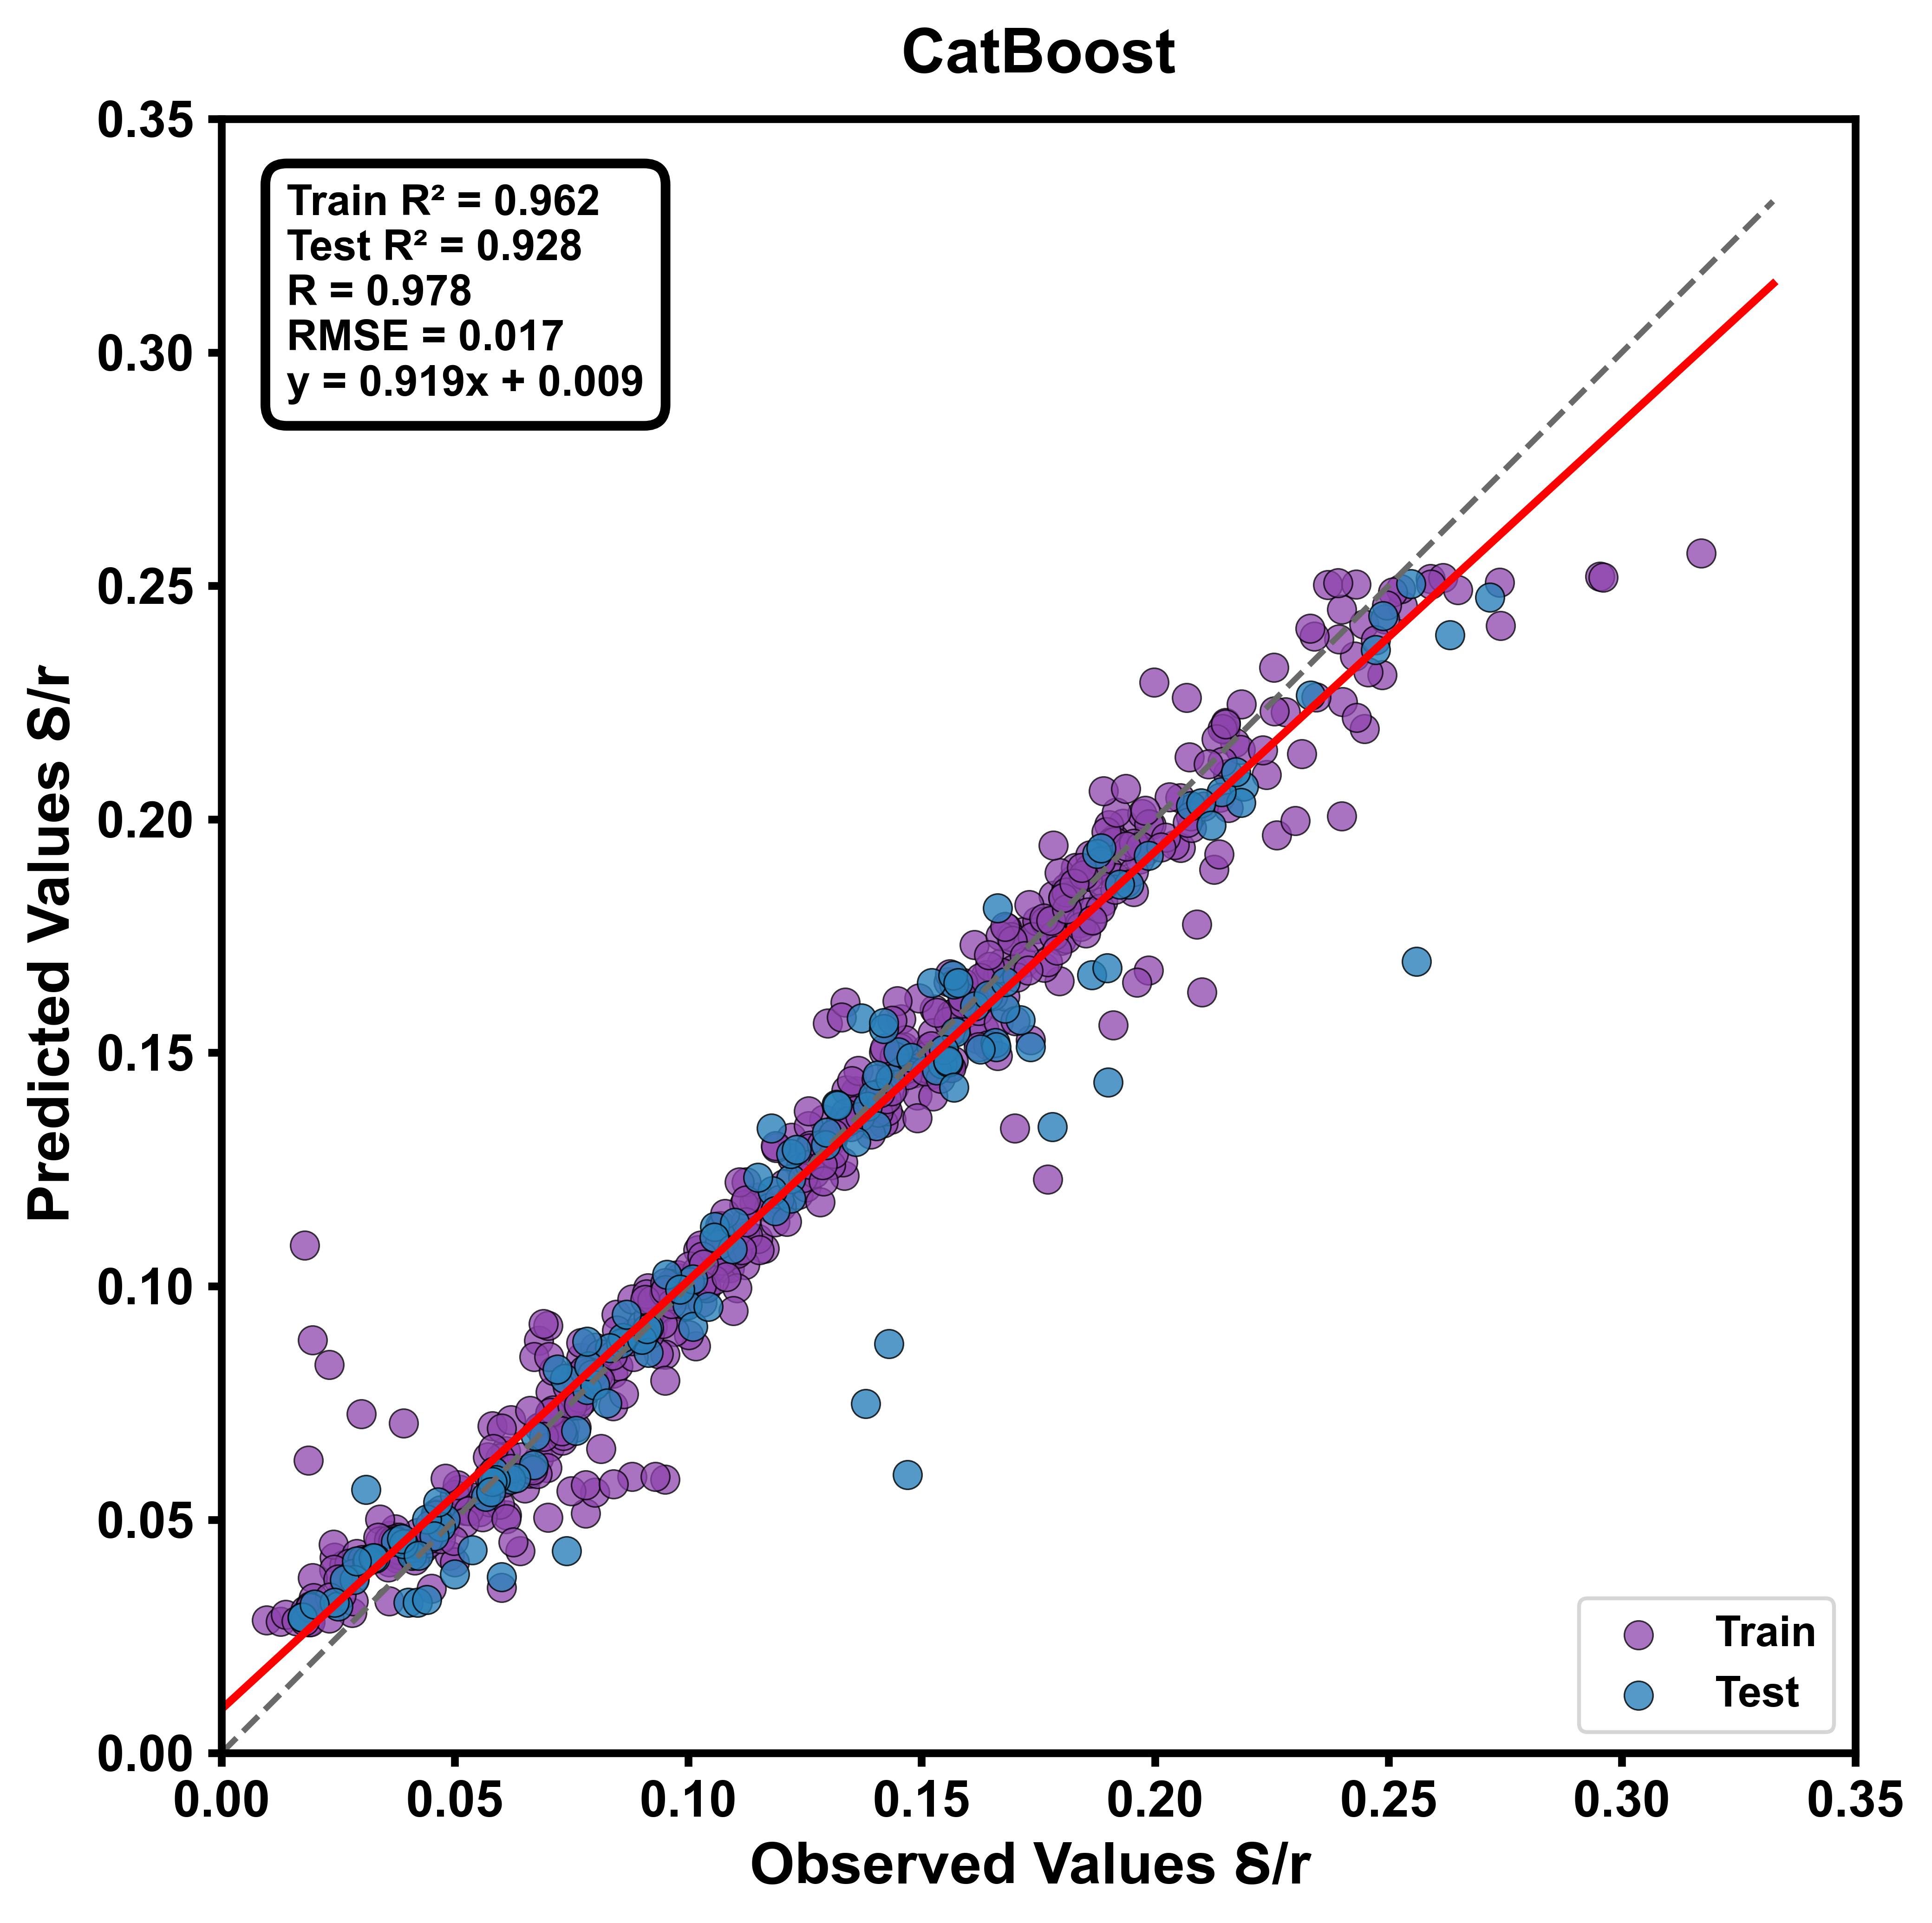


Feature Importance (%):
Ca    57.66
We    22.81
Re    19.52
dtype: float64


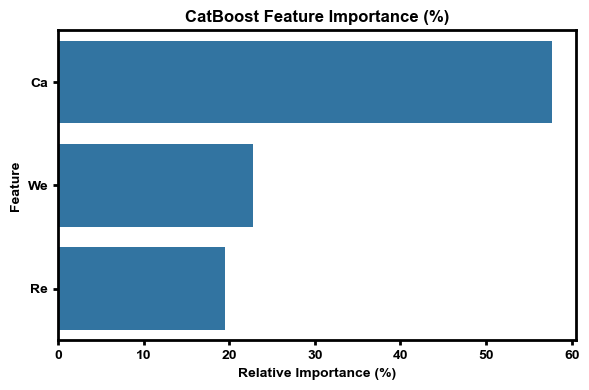


SHAP Analysis...


 98%|===================| 131/134 [00:11<00:00]       

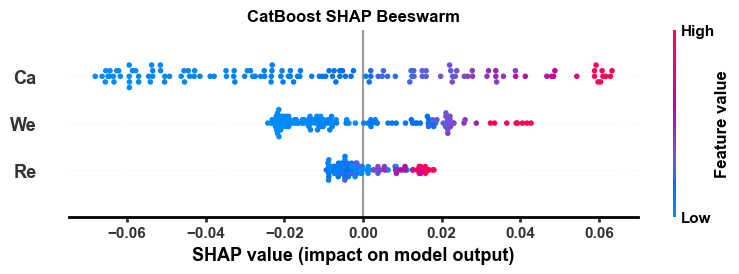

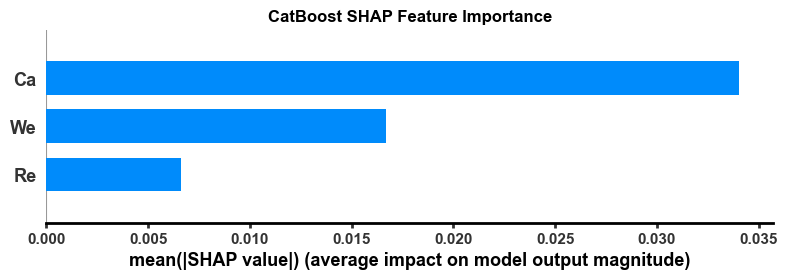


SHAP Feature Ranking:
Ca    0.034008
We    0.016693
Re    0.006606
dtype: float64


In [14]:
# 11. Loop through models

results = []

os.makedirs(OUTPUT_DIR, exist_ok=True)

for name, model in models.items():

    print(f"\n========== {name} ==========")

    # -------------------------------
    # Train Model
    # -------------------------------
    model.fit(X_train_scaled, y_train)
    # -------------------------------
    # Predictions
    # -------------------------------
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    # -------------------------------
    # Metrics
    # -------------------------------
    r2 = r2_score(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_test_pred)

    print(f"R²   : {r2:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAPE : {mape:.4f}")

    results.append([name, r2, mse, rmse, mape])

    # -------------------------------
    # Regression Plot
    # -------------------------------
    regression_plot(
        y_train,
        y_train_pred,
        y_test,
        y_test_pred,
        model_name=name
    )

    # -------------------------------
    # Feature Importance
    # -------------------------------
       # Feature Importance (%)
    # -------------------------------
    if hasattr(model, "feature_importances_"):

        importance = pd.Series(
            model.feature_importances_,
            index=features
        )

        importance_pct = (
            importance / importance.sum()
        ) * 100

        importance_pct = (
            importance_pct
            .sort_values(ascending=False)
        )

        print("\nFeature Importance (%):")
        print(importance_pct.round(2))

        plt.figure(figsize=(6, 4))

        ax = sns.barplot(
            x=importance_pct.values,
            y=importance_pct.index
        )

        # for i, v in enumerate(
        #     importance_pct.values
        # ):
        #     ax.text(
        #         v + 0.5,
        #         i,
        #         f"{v:.1f}%",
        #         va='center'
        #     )

        plt.title(
            f"{name} Feature Importance (%)"
        )

        plt.xlabel(
            "Relative Importance (%)"
        )

        plt.ylabel(
            "Feature"
        )

        plt.tight_layout()

        plt.savefig(
            os.path.join(
                OUTPUT_DIR,
                f"{name}_Feature_Importance_Percent.png"
            ),
            dpi=600,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

    # -------------------------------
    # SHAP Analysis
    # -------------------------------
    print("\nSHAP Analysis...")

    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_test)

    # -------------------------------
    # SHAP Beeswarm
    # -------------------------------
    shap.summary_plot(
        shap_values,
        X_test,
        max_display=len(features),
        show=False
    )

    plt.title(
        f"{name} SHAP Beeswarm",
        fontsize=12,
        fontweight="bold"
    )

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"{name}_SHAP_Beeswarm.png"
        ),
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    # -------------------------------
    # SHAP Bar Plot
    # -------------------------------
    shap.summary_plot(
        shap_values,
        X_test,
        plot_type="bar",
        max_display=len(features),
        show=False
    )

    plt.title(
        f"{name} SHAP Feature Importance",
        fontsize=12,
        fontweight="bold"
    )

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"{name}_SHAP_Bar.png"
        ),
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    # -------------------------------
    # SHAP Ranking
    # -------------------------------
    shap_importance = np.abs(
        shap_values.values
    ).mean(axis=0)

    shap_importance = pd.Series(
        shap_importance,
        index=features
    ).sort_values(ascending=False)

    print("\nSHAP Feature Ranking:")
    print(shap_importance)

# End-------------------------------

In [15]:
# 12. Results Table

results_df = pd.DataFrame(
    results,
    columns=["Model", "R²", "MSE", "RMSE", "MAPE"]
)

results_df = results_df.sort_values(
    by="R²",
    ascending=False
)

print("\nModel Comparison:")
print(results_df)


Model Comparison:
           Model        R²       MSE      RMSE      MAPE
3       CatBoost  0.928239  0.000284  0.016847  0.114735
2        XGBoost  0.927771  0.000286  0.016902  0.099871
0  Random Forest  0.912927  0.000344  0.018557  0.105730
1       LightGBM  0.891919  0.000427  0.020675  0.144436
